In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
file_path = '/content/Indeks Pemberdayaan Gender (IDG), 2021-2023.csv'
data = pd.read_csv(file_path, delimiter=';')

In [ ]:
data_cleaned = data.iloc[2:].reset_index(drop=True)
data_cleaned.columns = ['Lokasi', '2021', '2022', '2023']

for col in ['2021', '2022', '2023']:
    data_cleaned[col] = pd.to_numeric(data_cleaned[col], errors='coerce')

data_cleaned = data_cleaned[(data_cleaned[['2021', '2022', '2023']] != 0).all(axis=1)]


Statistik Deskriptif:
             2021        2022        2023
count  552.000000  552.000000  552.000000
mean    64.909040   65.467355   65.769384
std      9.611508    9.412355    9.602641
min     34.540000   28.700000   27.240000
25%     58.450000   59.040000   59.017500
50%     65.655000   65.965000   66.395000
75%     71.660000   72.415000   72.710000
max     88.710000   89.150000   89.290000


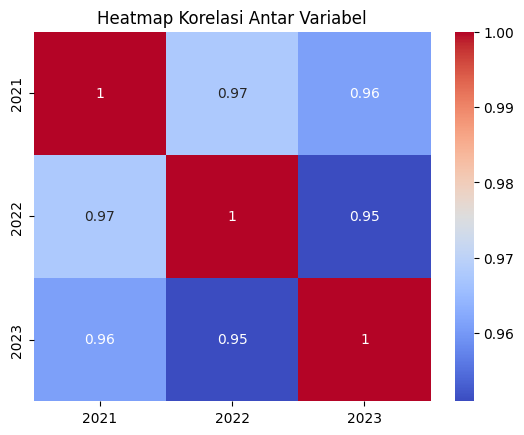

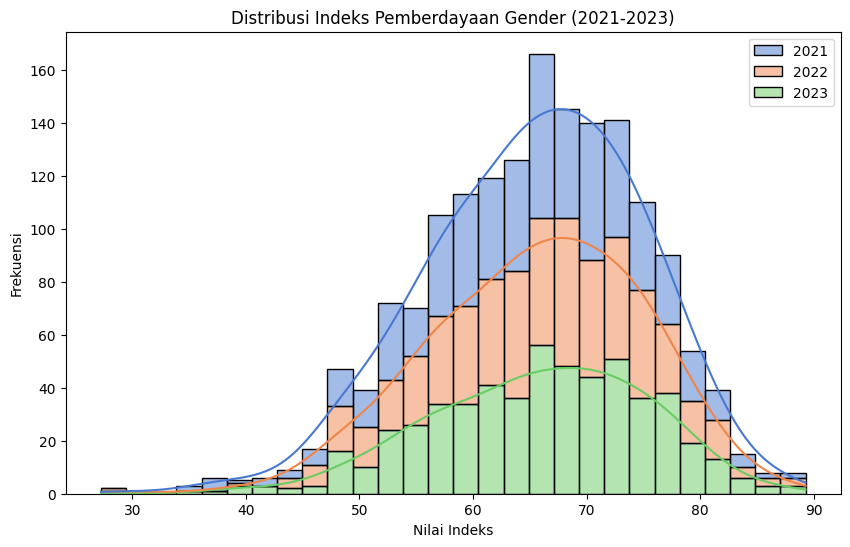

In [ ]:
print("\nStatistik Deskriptif:")
print(data_cleaned.describe())

numeric_data = data_cleaned[['2021', '2022', '2023']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(numeric_data, kde=True, palette='muted', multiple='stack')
plt.title('Distribusi Indeks Pemberdayaan Gender (2021-2023)')
plt.xlabel('Nilai Indeks')
plt.ylabel('Frekuensi')
plt.show()


Distribusi Label:
Label
Rendah    351
Tinggi    201
Name: count, dtype: int64


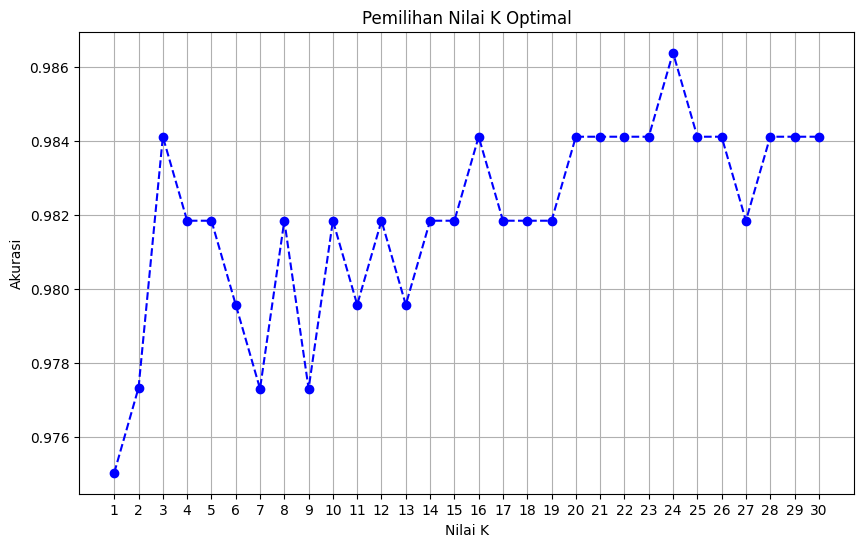

Nilai K Optimal: 24

Evaluasi KNN:
Akurasi: 0.990990990990991

Classification Report:
               precision    recall  f1-score   support

      Rendah       1.00      0.99      0.99        68
      Tinggi       0.98      1.00      0.99        43

    accuracy                           0.99       111
   macro avg       0.99      0.99      0.99       111
weighted avg       0.99      0.99      0.99       111



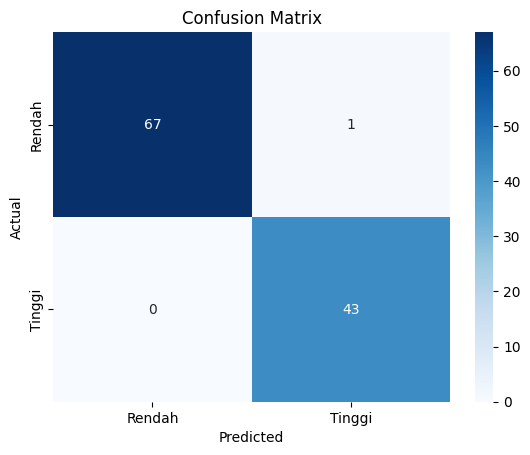

In [ ]:
X = data_cleaned[['2021', '2022', '2023']]
data_cleaned['Label'] = np.where(data_cleaned['2023'] > 70, 'Tinggi', 'Rendah')
y = data_cleaned['Label']

print("\nDistribusi Label:")
print(data_cleaned['Label'].value_counts())

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def find_optimal_k(X_train, y_train):
    k_range = range(1, 31)
    scores = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        scores.append(score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, scores, marker='o', linestyle='--', color='b')
    plt.xticks(k_range)
    plt.xlabel('Nilai K')
    plt.ylabel('Akurasi')
    plt.title('Pemilihan Nilai K Optimal')
    plt.grid()
    plt.show()

    optimal_k = k_range[np.argmax(scores)]
    print(f"Nilai K Optimal: {optimal_k}")
    return optimal_k

k = find_optimal_k(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\nEvaluasi KNN:")
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rendah', 'Tinggi'], yticklabels=['Rendah', 'Tinggi'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
def display_top_n_lowest(data, year, n):
    print(f"\n{n} Provinsi dengan Nilai Indeks Terendah pada Tahun {year}:")
    print(data[['Lokasi', year]].nsmallest(n, year))

for year in ['2021', '2022', '2023']:
    display_top_n_lowest(data_cleaned, year, 3)


3 Provinsi dengan Nilai Indeks Terendah pada Tahun 2021:
               Lokasi   2021
518          TAMBRAUW  34.54
549           DOGIYAI  35.22
521  PEGUNUNGAN ARFAK  36.36

3 Provinsi dengan Nilai Indeks Terendah pada Tahun 2022:
                 Lokasi   2022
537  PEGUNUNGAN BINTANG  28.70
550          INTAN JAYA  31.41
518            TAMBRAUW  38.64

3 Provinsi dengan Nilai Indeks Terendah pada Tahun 2023:
               Lokasi   2023
545        LANNY JAYA  27.24
550        INTAN JAYA  35.89
521  PEGUNUNGAN ARFAK  38.21


In [ ]:
X_reg = np.array([2021, 2022, 2023]).reshape(-1, 1)

In [ ]:
def predict_2024(data):
    predicted_values = []

    for i, row in data.iterrows():
        y_reg = row[['2021', '2022', '2023']].values
        model = LinearRegression()
        model.fit(X_reg, y_reg)
        predicted_values.append(model.predict([[2024]])[0])

    data['Predicted_2024'] = predicted_values
    return data

In [ ]:
data_cleaned = predict_2024(data_cleaned)

In [ ]:
actual = data_cleaned[['2021', '2022', '2023']].mean(axis=1)
predicted = data_cleaned['Predicted_2024']
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print(f"\nEvaluasi Linear Regression:\nRMSE: {rmse:.2f}\nR²: {r2:.2f}")


Evaluasi Linear Regression:
RMSE: 2.81
R²: 0.91


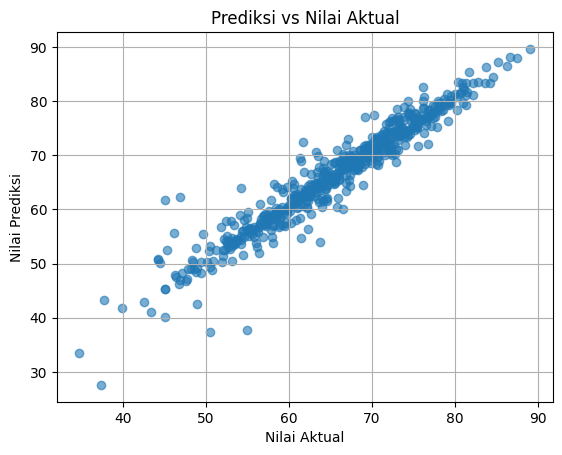

In [ ]:
plt.scatter(actual, predicted, alpha=0.6)
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Prediksi vs Nilai Aktual")
plt.grid()
plt.show()


5 Provinsi dengan Nilai Indeks Terprediksi Terendah pada Tahun 2024:
          Lokasi  Predicted_2024
545   LANNY JAYA       27.593333
550   INTAN JAYA       33.563333
531  PUNCAK JAYA       37.300000
530       PANIAI       37.800000
544        NDUGA       40.053333


<ipython-input-55-6d969fde7bf8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_2024', y='Lokasi', data=lowest_predicted_provinces, palette='Reds_r')


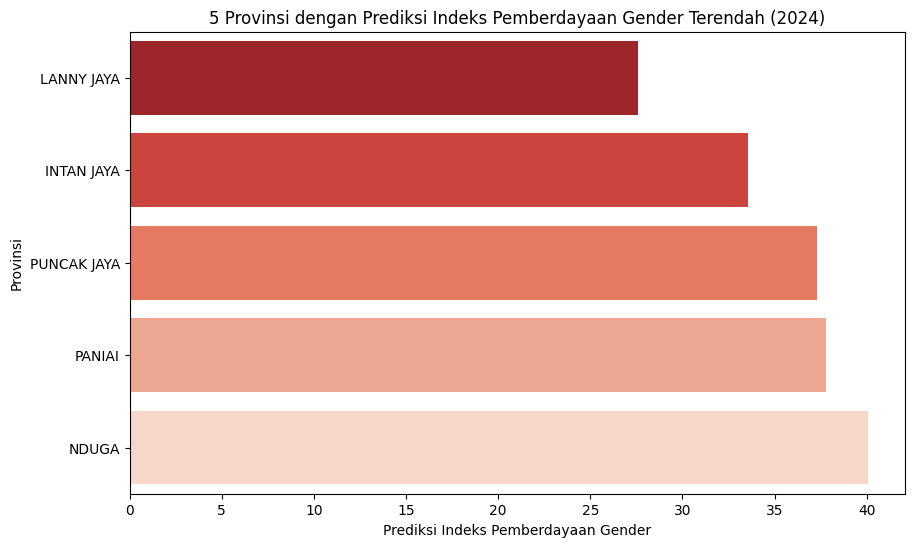

In [ ]:
lowest_predicted_provinces = data_cleaned[['Lokasi', 'Predicted_2024']].nsmallest(5, 'Predicted_2024')
print("\n5 Provinsi dengan Nilai Indeks Terprediksi Terendah pada Tahun 2024:")
print(lowest_predicted_provinces)

plt.figure(figsize=(10, 6))
sns.barplot(x='Predicted_2024', y='Lokasi', data=lowest_predicted_provinces, palette='Reds_r')
plt.title('5 Provinsi dengan Prediksi Indeks Pemberdayaan Gender Terendah (2024)')
plt.xlabel('Prediksi Indeks Pemberdayaan Gender')
plt.ylabel('Provinsi')
plt.show()